In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve
from src.curves.simulator.hull_white_2factor import HullWhite2FactorSimulator
from src.curves.simulator.hull_white_2factor_pricer import HullWhite2FactorPricer

from src.instruments.instrument_builder import InstrumentBuilder

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [3]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [4]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [5]:
# HW 2-factor short-rate simulator engine
# short rate
r0 = zero_curve.get_zero_rate(maturity = 0.25)

# HW engine
hw_engine = HullWhite2FactorSimulator(
    r0 = r0,
    random_seed = 2
)

# single path simulator
single_path = hw_engine.simulate_single_path(
    maturity = 10.0,
    steps_per_year = 12
)

print(f'Short-rate: {r0:.6f}')

single_path

Short-rate: 0.035845


,Time,Factor1,Factor2,ShortRate
0,0.000000,0.000000,0.000000,0.035845
1,0.083333,-0.001203,-0.000229,0.034413
2,0.166667,-0.007360,0.001302,0.029787
3,0.250000,-0.012476,-0.000576,0.022793
4,0.333333,-0.010920,-0.002111,0.022814
...,...,...,...,...
117,9.750000,0.003183,0.003537,0.042565
118,9.833333,0.000202,0.002394,0.038441
119,9.916667,-0.007032,0.003942,0.032755
120,10.000000,-0.011922,0.003052,0.026975


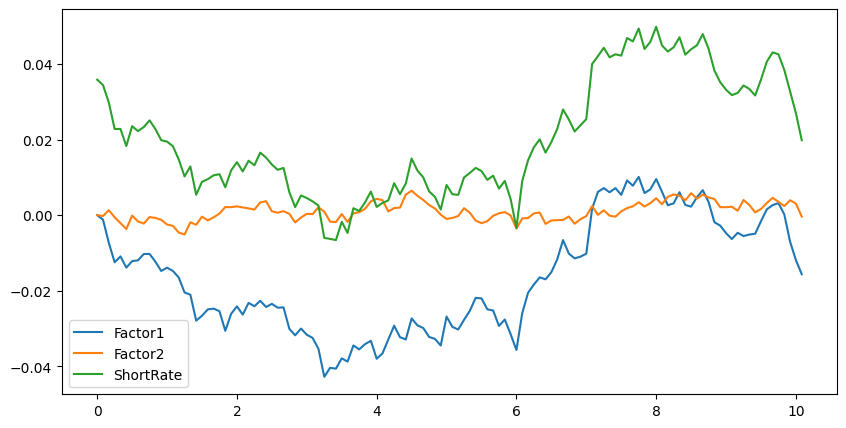

In [6]:
# plot hw 2-factor short-rate simulation
plt.figure(figsize = (10, 5))

plt.plot(single_path['Time'], single_path['Factor1'], label = 'Factor1')
plt.plot(single_path['Time'], single_path['Factor2'], label = 'Factor2')
plt.plot(single_path['Time'], single_path['ShortRate'], label = 'ShortRate')

plt.legend(loc = 'best')
plt.show()

In [7]:
paths = hw_engine.simulate_multi_paths(
    maturity = 10.0,
    n_paths = 10000,
    steps_per_year = 12
)

f1 = paths['Factor1']
f2 = paths['Factor2']

corr = np.corrcoef(
    x = f1[:, -1],
    y = f2[:, -1]
)[0, 1]

print(corr)

0.18899549668219248


In [13]:
# Hull-White bond pricer 
hw_pricer = HullWhite2FactorPricer(zero_curve = zero_curve)

bond = hw_pricer.bond_price(
    t = 1.0,
    T = 5.0,
    x_t = 0.01,
    y_t = 0.002
)

bond

0.8392399590251822